lambda_no_turbine = - (numero di turbine)^2 * potenza_nominale
lambda_distanza = - 1 * potenza nominale  

# 1. Define QUBO matrix

In [14]:
import sys
import numpy as np


sys.path.append("..")
from src.qubo_windfarm_layout.model import get_farm_area, get_mask, build_qubo_from_wake_matrix_optimized, build_wake_loss_matrix_optimized, build_wake_loss_matrix_optimized, load_wake_loss_data
from src.qubo_windfarm_layout.visualization import plot_selected_layout
from src.solvers.utils import get_invalid_pairs
from src.solvers.ortools import solve_wflo_cpsat
from src.solvers.utils import save_benchmark_layout

In [15]:
# Variables
GRID_RESOLUTION = 200 # m
MIN_DISTANCE = 396  # 2 * 198 m

# Get candidates
polygons, farm_area = get_farm_area()
X, Y, mask = get_mask(farm_area=farm_area, grid_resolution=GRID_RESOLUTION)

candidate_locations = np.column_stack([
    X[mask],
    Y[mask],
])

print(f"Filtered candidates shape {candidate_locations.shape}")

# Invalid pairs constraint
invalid_pairs = get_invalid_pairs(candidate_locations=candidate_locations, min_distance=MIN_DISTANCE)

Filtered candidates shape (905, 2)


In [16]:
# Matrix definition
# build_wake_loss_matrix_optimized(
#     candidate_locations,
#     grid_resolution=GRID_RESOLUTION,
#     output_path=f"../results/precomputed/wake_loss_{GRID_RESOLUTION}m.npz"
# )

wake_loss = load_wake_loss_data(f"../results/precomputed/wake_loss_{GRID_RESOLUTION}m.npz")
wake_loss_matrix = wake_loss["wake_loss_matrix"]
A0 = wake_loss["A0"]

Q, offset = build_qubo_from_wake_matrix_optimized(
    wake_loss_matrix,
    invalid_pairs,
    A0,
    n_turbines=81,
    lambda_cardinality=40000,
    lambda_spacing=1e-6
)

# 2. Solvers

## 2.1 OR Tools - CPSAT

In [ ]:
time_limit_s = 60*60

z_solution, solver = solve_wflo_cpsat(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    time_limit_s=time_limit_s,
    num_workers=8,
)

selected_locations = candidate_locations[
    z_solution.astype(bool)
]

plot_selected_layout(selected_locations=selected_locations)

save_benchmark_layout(
    selected_locations=selected_locations,
    solver_name="cpsat",
    filename=f"cpsat_{GRID_RESOLUTION}_{time_limit_s}s.yaml",
    grid_resolution=GRID_RESOLUTION,
    time_limit_s=time_limit_s
)

## 2.2 OR Tools - SCIP

presolving:
(round 1, exhaustive) 0 del vars, 0 del conss, 0 add conss, 1 chg bounds, 0 chg sides, 0 chg coeffs, 3152 upgd conss, 0 impls, 3152 clqs, 0 implints
(round 2, exhaustive) 0 del vars, 0 del conss, 3652 add conss, 1 chg bounds, 0 chg sides, 138 chg coeffs, 3153 upgd conss, 0 impls, 3152 clqs, 1087 implints
   (18.4s) probing: 1000/1992 (50.2%) - 0 fixings, 0 aggregations, 466453 implications, 0 bound changes
   (18.4s) probing: 1001/1992 (50.3%) - 0 fixings, 0 aggregations, 466980 implications, 0 bound changes
   (18.4s) probing aborted: 1000/1000 successive useless probings
   Deactivated symmetry handling methods, since SCIP was built without symmetry detector (SYM=none).
   Deactivated symmetry handling methods, since SCIP was built without symmetry detector (SYM=none).
presolving (3 rounds: 3 fast, 3 medium, 3 exhaustive):
 1 deleted vars, 1 deleted constraints, 3652 added constraints, 1 tightened bounds, 0 added holes, 0 changed sides, 138 changed coefficients
 855 impli

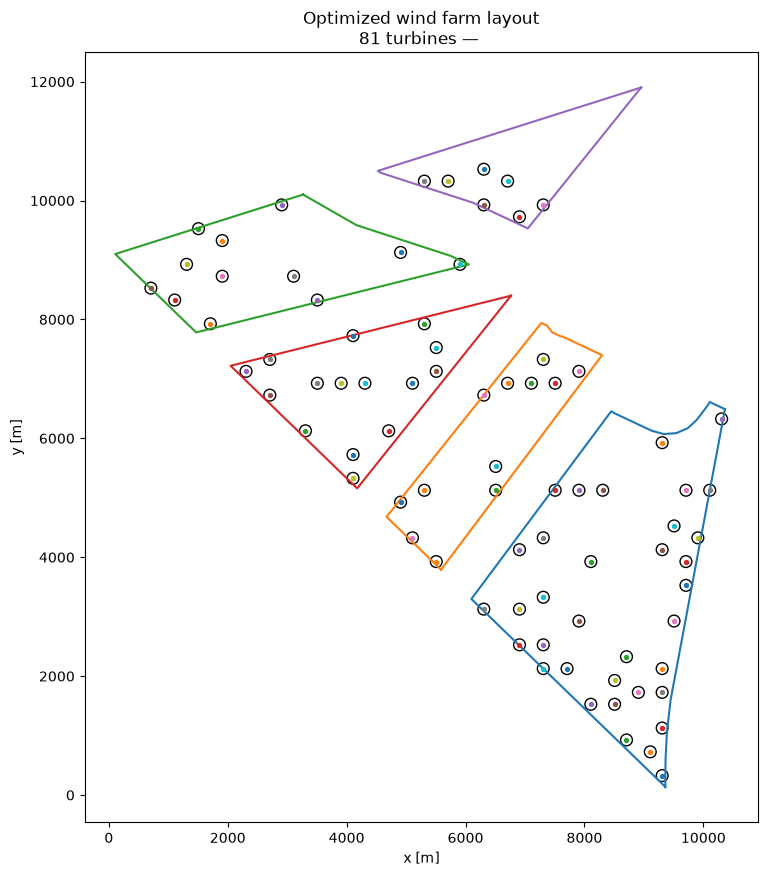

Layout saved to: /home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/scip_200_120s.yaml


PosixPath('/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/scip_200_120s.yaml')

In [9]:
from src.solvers.ortools import solve_wflo_gscip

time_limit_s = 60*2

z_solution_scip, _ = solve_wflo_gscip(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    time_limit_s=time_limit_s,
)

selected_locations_scip = candidate_locations[
    z_solution_scip.astype(bool)
]

plot_selected_layout(selected_locations=selected_locations_scip)

save_benchmark_layout(
    selected_locations=selected_locations_scip,
    solver_name="scip",
    filename=f"scip_{GRID_RESOLUTION}_{time_limit_s}s.yaml",
    grid_resolution=GRID_RESOLUTION,
    time_limit_s=time_limit_s
)

## 2.3 D-Wave Simulated Annealing

n = 905 variabili, sampler_type = 'simulated_annealing'
BQM: 905 variabili, 409,060 interazioni (0.5s)
Campionamento completato in 794.2s
Campioni con 81 turbine: 1000/1000
Turbine selezionate: 81
Pairwise wake loss: 953393.1922


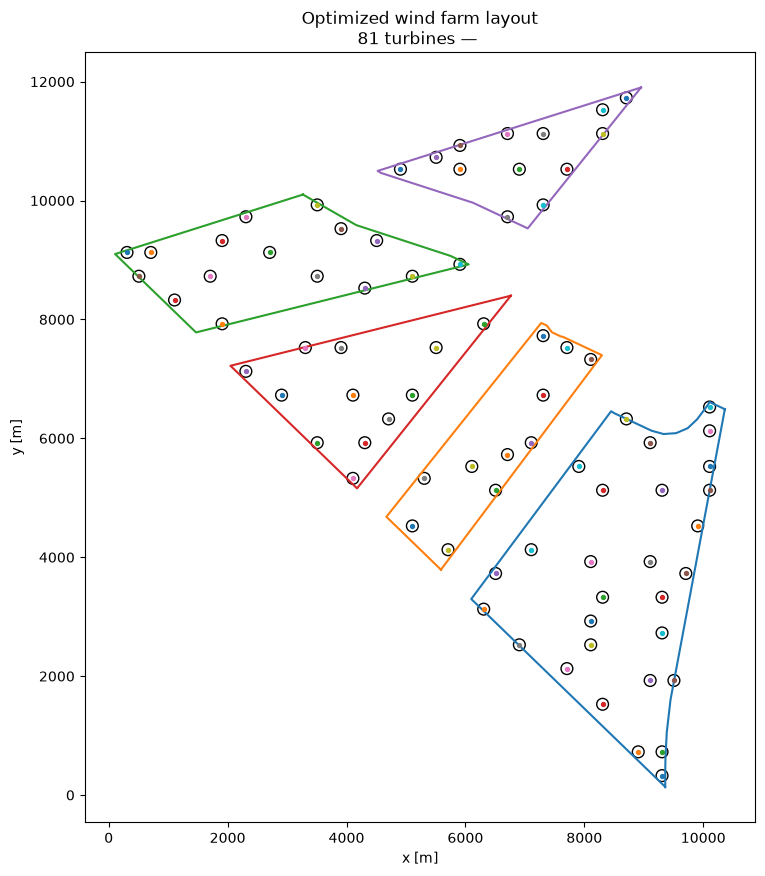

Layout saved to: /home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/dwave_sa_200_1000reads_20000sweeps.yaml


PosixPath('/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/dwave_sa_200_1000reads_20000sweeps.yaml')

In [13]:
from src.solvers.dwave import solve_wflo_dwave
from src.solvers.utils import save_benchmark_layout

NUM_READS = 1000
NUM_SWEEPS = 20000

z_dwave, sampleset = solve_wflo_dwave(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    Q=Q,
    n_turbines=81,
    sampler_type="simulated_annealing",
    num_reads=NUM_READS,   # Dimezzare read e quadruplicare sweep costa lo stesso tempo
    num_sweeps=NUM_SWEEPS, # num_sweeps >= 10 x n variables
    seed=42,
)
selected_locations_dwave = candidate_locations[z_dwave.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_dwave)
save_benchmark_layout(
    selected_locations=selected_locations_dwave,
    solver_name="dwave_sa",
    filename=f"dwave_sa_{GRID_RESOLUTION}_{NUM_READS}reads_{NUM_SWEEPS}sweeps.yaml",
    grid_resolution=GRID_RESOLUTION,
)

## 2.4 SQBM+

In [9]:
from src.solvers.sqbm import SQBMClient, solve_wflo_sqbm

SQBM_HOST = "20.229.234.199"
SQBM_PORT = 8000

client = SQBMClient(host=SQBM_HOST, port=SQBM_PORT, timeout=1200, problem_format="hdf5")

print("Health check:", client.health_check())
print("Version:     ", client.version())

Health check: True
Version:      2.1.3


n = 905 variabili, SQBM+ @ 20.229.234.199:8000 (hdf5)
Campionamento completato in 81.8s  (server: 80.0s)
Turbine selezionate: 81
Pairwise wake loss: 888686.2096


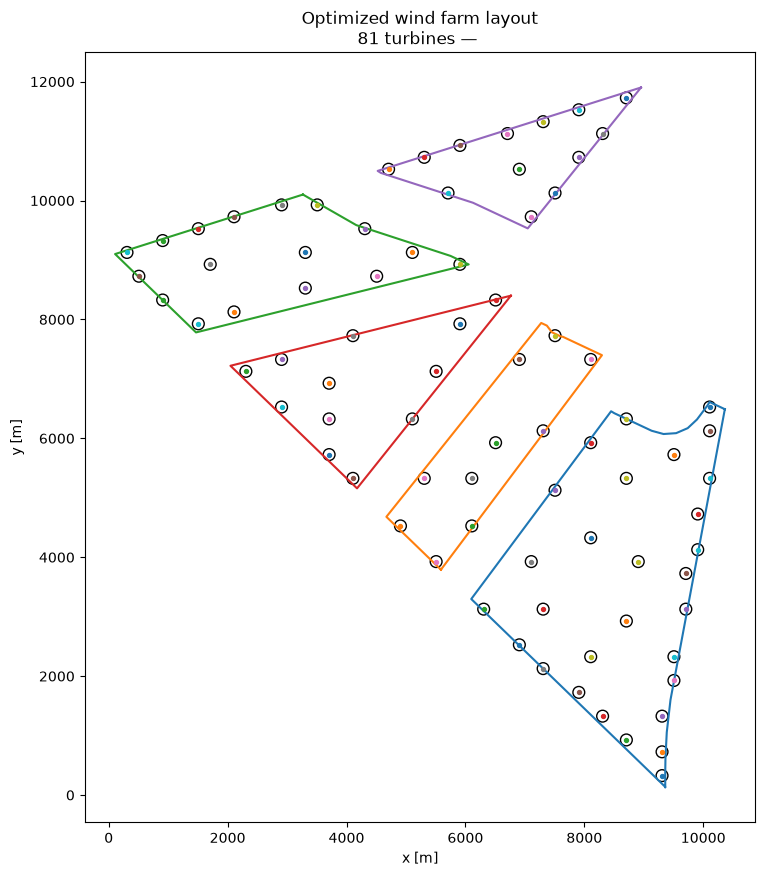

Layout saved to: /home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/sqbm_200_0algo_80s.yaml


PosixPath('/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/sqbm_200_0algo_80s.yaml')

In [13]:
TIMEOUT = 80
ALGO = 0

solution, sqbm_result = solve_wflo_sqbm(
    wake_loss_matrix,
    invalid_pairs,
    Q,
    host=SQBM_HOST,
    port=SQBM_PORT,
    timeout=TIMEOUT,
    algo=ALGO,
)
selected_locations_sqbm = candidate_locations[solution.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_sqbm)
save_benchmark_layout(
    selected_locations=selected_locations_sqbm,
    solver_name="sqbm",
    filename=f"sqbm_{GRID_RESOLUTION}_{ALGO}algo_{TIMEOUT}s.yaml",
    grid_resolution=GRID_RESOLUTION,
)

# Solvers

| Categoria                        | Solver                       |
| -------------------------------- | ---------------------------- |
| Exact / mathematical programming | **Gurobi**                   |
| CP/SAT                           | **OR-Tools CP-SAT**          |
| SCIP                             | **OR-Tools GSCIP**           |
| HiGHS                            | **OR-Tools HiGHS**           |
| Classical hybrid heuristic       | **Hexaly**                   |
| QUBO classical baseline          | **Simulated Annealing**      |
| QUBO classical baseline          | **D-Wave Tabu**              |
| Quantum-inspired                 | **Toshiba SQBM+**            |
| Quantum-inspired                 | **Fujitsu Digital Annealer** |

In [ ]:
# TODO
# Capire se usare base.yaml come starting point (warmstart) può creare dei vantaggi per i solutori quantum